In [1]:
import pandas as pd
import numpy as np 
import duckdb 

In [2]:
con = duckdb.connect('../data/database/ne_pipeline.db')


In [3]:
con.execute("""
            SHOW TABLES
""").fetchall()


[('merged',), ('merged_view',), ('train_delay',), ('weather',)]

In [4]:
train = con.sql("""
        SELECT * FROM train_delay
""")
weather = con.sql("""
        SELECT * FROM weather
""")

con.execute("""
    CREATE VIEW IF NOT EXISTS merged_view AS
        SELECT td.*, 
               w.temperature_2m_max,
               w.temperature_2m_min,
               w.temperature_2m_mean,
               w.precipitation_sum,
               w.rain_sum,
               w.wind_speed_10m_max,
               w.wind_gusts_10m_max,
               w.relative_humidity_2m_mean,
               w.weather_code
        FROM train_delay td
        INNER JOIN weather w
            ON td.train_no = w.train_no
            AND td.date = w.date
""")

merged = con.sql("SELECT * FROM merged_view")
merged.df().info()

<class 'pandas.DataFrame'>
RangeIndex: 120757 entries, 0 to 120756
Data columns (total 13 columns):
 #   Column                     Non-Null Count   Dtype         
---  ------                     --------------   -----         
 0   train_no                   120757 non-null  str           
 1   date                       120757 non-null  datetime64[us]
 2   station                    120757 non-null  str           
 3   delay_minutes              108412 non-null  Int32         
 4   temperature_2m_max         120757 non-null  float64       
 5   temperature_2m_min         120757 non-null  float64       
 6   temperature_2m_mean        120757 non-null  float64       
 7   precipitation_sum          120757 non-null  float64       
 8   rain_sum                   120757 non-null  float64       
 9   wind_speed_10m_max         120757 non-null  float64       
 10  wind_gusts_10m_max         120757 non-null  float64       
 11  relative_humidity_2m_mean  120757 non-null  float64       
 12 

In [5]:
'''[ASSERT] Every date in train data exists in weather data, and vice versa'''

def assert_dates(df_ts,df_w):
    ts_dates = set(df_ts['date'].dt.date)
    w_dates = set(df_w['date'].dt.date)
    #set difference
    missing_in_weather = ts_dates - w_dates
    missing_in_train = w_dates - ts_dates

    assert not missing_in_weather and not missing_in_train,(
        f"Mismatch!\n"
        f"Missing in weather: {missing_in_weather}\n"
        f"Extra in weather: {missing_in_train}"
    )

''' [ASSERT] a lossless merge of two dataset '''
def assert_lossless_join(df_merged,df_ts):
    #row mismatch
    assert df_merged.shape[0] ==  df_ts.shape[0]
    #duplicate rows
    assert df_merged.duplicated(subset=['train_no','date','station']).sum() == 0

    
'''[ASSERT] weather columns are not null post-join '''
def assert_weather_col(df_merged,df_w):
    df_weather_col = [col for col in df_w.columns if col not in ('date','train_no')]
    assert df_merged[df_weather_col].isna().sum().sum() == 0,(
        "Mismatch \n",
        f"{df_merged[df_weather_col].isna().sum()}"
    )

assert_lossless_join(merged.to_df(),train.to_df())
assert_weather_col(merged.to_df(),weather.to_df())
assert_dates(train.to_df(),weather.to_df())

In [ ]:
''' 
Descriptive — which trains/routes/stations are worst overall
Temporal — day of week, month, season patterns
Weather correlation — rain/fog vs delay magnitude
Combined — a simple regression or feature importance showing which factor matters most
'''

' \nDescriptive — which trains/routes/stations are worst overall\nTemporal — day of week, month, season patterns\nWeather correlation — rain/fog vs delay magnitude\nCascading analysis — does delay grow along the route?\nCombined — a simple regression or feature importance showing which factor matters most\n'

In [7]:
merged.to_df().info()

<class 'pandas.DataFrame'>
RangeIndex: 120757 entries, 0 to 120756
Data columns (total 13 columns):
 #   Column                     Non-Null Count   Dtype         
---  ------                     --------------   -----         
 0   train_no                   120757 non-null  str           
 1   date                       120757 non-null  datetime64[us]
 2   station                    120757 non-null  str           
 3   delay_minutes              108412 non-null  Int32         
 4   temperature_2m_max         120757 non-null  float64       
 5   temperature_2m_min         120757 non-null  float64       
 6   temperature_2m_mean        120757 non-null  float64       
 7   precipitation_sum          120757 non-null  float64       
 8   rain_sum                   120757 non-null  float64       
 9   wind_speed_10m_max         120757 non-null  float64       
 10  wind_gusts_10m_max         120757 non-null  float64       
 11  relative_humidity_2m_mean  120757 non-null  float64       
 12 

In [8]:
'''  which trains/stations are worst overall '''
con.sql("""
	select 
        train_no,
        ROUND(avg(delay_minutes),2) as avg_delay,
        ROUND(median(delay_minutes),2) as median_delay,
        MIN(delay_minutes) as min_delay,
        MAX(delay_minutes) as max_delay,
        COUNT(*) - COUNT(delay_minutes) as missing_data
    from merged_view
    group by train_no
    order by avg_delay desc
""")


┌──────────┬───────────┬──────────────┬───────────┬───────────┬──────────────┐
│ train_no │ avg_delay │ median_delay │ min_delay │ max_delay │ missing_data │
│ varchar  │  double   │    double    │   int32   │   int32   │    int64     │
├──────────┼───────────┼──────────────┼───────────┼───────────┼──────────────┤
│ 15657    │      77.6 │         23.0 │       -53 │       744 │         1245 │
│ 15909    │     76.83 │         45.0 │       -42 │       970 │         4367 │
│ 15615    │     64.84 │         55.0 │       -44 │      2949 │         1512 │
│ 15946    │      41.4 │         24.0 │       -34 │       703 │          181 │
│ 12505    │     39.48 │         24.0 │       -11 │       732 │         2061 │
│ 15960    │     38.34 │         19.0 │       -47 │       963 │         1075 │
│ 12423    │     32.23 │         15.0 │       -24 │       696 │          751 │
│ 12346    │     29.92 │         13.0 │       -45 │       503 │          612 │
│ 12067    │      9.49 │          8.0 │       -26 │ 

In [9]:
con.sql("""SELECT 
    station,
    ROUND(AVG(delay_minutes), 2) AS avg_delay,
    ROUND(MEDIAN(delay_minutes), 2) AS median_delay,
    COUNT(DISTINCT train_no) AS trains_through_station
FROM merged_view
GROUP BY station
HAVING trains_through_station>1
ORDER BY avg_delay DESC"""
)

┌─────────┬───────────┬──────────────┬────────────────────────┐
│ station │ avg_delay │ median_delay │ trains_through_station │
│ varchar │  double   │    double    │         int64          │
├─────────┼───────────┼──────────────┼────────────────────────┤
│ MKA     │     98.23 │         59.0 │                      2 │
│ BJF     │     79.95 │         32.0 │                      3 │
│ SBE     │     78.61 │         34.0 │                      2 │
│ FKM     │      77.4 │         29.0 │                      2 │
│ PNC     │     75.99 │         42.0 │                      2 │
│ GOGH    │     75.19 │         32.0 │                      3 │
│ SM      │     71.28 │         25.0 │                      2 │
│ BNGN    │     69.25 │         26.0 │                      2 │
│ PNBE    │      67.2 │         28.5 │                      2 │
│ MZP     │     65.94 │         33.0 │                      2 │
│  ·      │       ·   │           ·  │                      · │
│  ·      │       ·   │           ·  │  

In [17]:
'''Temporal — day of week, month, season patterns'''
'''1 Which day has the highest average delay'''
con.sql("""
	SELECT 
        DAYNAME(date) as day,
        ROUND(AVG(delay_minutes), 2) AS avg_delay,
    	ROUND(MEDIAN(delay_minutes), 2) AS median_delay,
        COUNT(*) as total_running_trains
    FROM merged_view
    GROUP BY  DAYNAME(date)
    ORDER BY avg_delay DESC
""")

┌───────────┬───────────┬──────────────┬──────────────────────┐
│    day    │ avg_delay │ median_delay │ total_running_trains │
│  varchar  │  double   │    double    │        int64         │
├───────────┼───────────┼──────────────┼──────────────────────┤
│ Friday    │     66.77 │         28.0 │                17368 │
│ Thursday  │     61.97 │         30.0 │                14469 │
│ Tuesday   │     58.33 │         31.0 │                17368 │
│ Sunday    │     56.94 │         30.0 │                16484 │
│ Monday    │     53.92 │         26.0 │                17368 │
│ Wednesday │     53.29 │         26.0 │                20332 │
│ Saturday  │     45.33 │         22.0 │                17368 │
└───────────┴───────────┴──────────────┴──────────────────────┘

In [18]:
'''2 Which month has the highest average delay'''
con.sql("""
	SELECT 
        MONTHNAME(date) as day,
        ROUND(AVG(delay_minutes), 2) AS avg_delay,
    	ROUND(MEDIAN(delay_minutes), 2) AS median_delay,
         COUNT(*) as total_running_trains
    FROM merged_view
    GROUP BY  MONTHNAME(date)
    ORDER BY avg_delay DESC
""")

┌───────────┬───────────┬──────────────┬──────────────────────┐
│    day    │ avg_delay │ median_delay │ total_running_trains │
│  varchar  │  double   │    double    │        int64         │
├───────────┼───────────┼──────────────┼──────────────────────┤
│ December  │    111.73 │         49.0 │                10327 │
│ January   │     92.43 │         50.0 │                10209 │
│ October   │     61.34 │         29.0 │                10266 │
│ November  │     58.75 │         29.0 │                 9919 │
│ April     │     55.12 │         35.0 │                 9932 │
│ February  │     52.63 │         31.0 │                 9268 │
│ March     │     48.98 │         28.0 │                10253 │
│ September │     45.87 │         22.0 │                 9936 │
│ July      │     42.74 │         18.0 │                10266 │
│ May       │     40.86 │         20.0 │                10209 │
│ June      │     39.02 │         17.0 │                 9919 │
│ August    │     31.72 │         16.0 │

In [16]:
con.sql("""SELECT 
    CASE 
        WHEN MONTH(date) IN (12,1,2) THEN 'Winter'
        WHEN MONTH(date) IN (3,4,5)  THEN 'Pre-Monsoon'
        WHEN MONTH(date) IN (6,7,8,9) THEN 'Monsoon'
        WHEN MONTH(date) IN (10,11)  THEN 'Post-Monsoon'
    END as season,
    ROUND(AVG(delay_minutes),2) as avg_delay,
    COUNT(*) as total_runs
FROM merged_view
GROUP BY season
ORDER BY avg_delay DESC""")

┌──────────────┬───────────┬────────────┐
│    season    │ avg_delay │ total_runs │
│   varchar    │  double   │   int64    │
├──────────────┼───────────┼────────────┤
│ Winter       │     86.73 │      29804 │
│ Post-Monsoon │     60.06 │      20185 │
│ Pre-Monsoon  │     48.53 │      30394 │
│ Monsoon      │     39.83 │      40374 │
└──────────────┴───────────┴────────────┘

<Axes: >

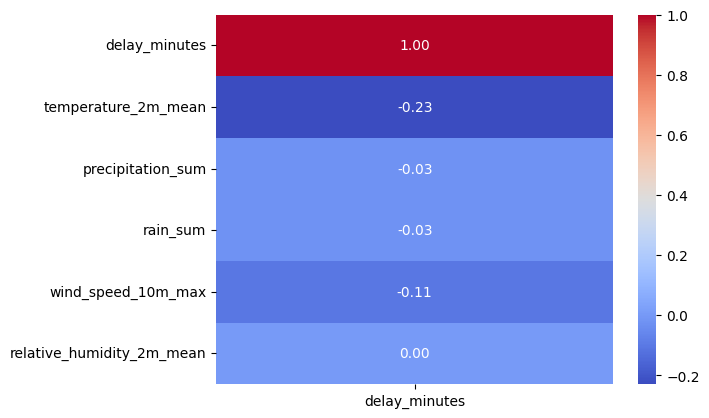

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = merged.to_df()[['delay_minutes','temperature_2m_mean','precipitation_sum',
           'rain_sum','wind_speed_10m_max','relative_humidity_2m_mean']].corr()[['delay_minutes']]

sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm')

In [ ]:
'''Contrary to the initial hypothesis that monsoon rainfall drives train delays in Northeast India, 
temperature is the strongest weather predictor (r = -0.23). Delays peak in winter (Dec-Jan avg 100+ min) 
and are lowest during monsoon (Aug avg 31 min), 
suggesting dense fog on Indo-Gangetic plain routes is the primary weather mechanism, not rain'''

In [22]:
df = merged.to_df()
df['is_fog'] = df['weather_code'].isin([45, 48])
df.groupby('is_fog')['delay_minutes'].mean()

is_fog
False    56.558794
Name: delay_minutes, dtype: Float64

In [25]:
df['weather_code'].value_counts()

weather_code
3     27200
63    24357
51    15340
65    11844
61    11135
0      9328
53     7688
1      6380
55     4119
2      3366
Name: count, dtype: int64

In [ ]:
'''Because fog is a morning phenomenon — it forms overnight and burns off by 10-11am once the sun comes up.
weather data is daily aggregates from Open-Meteo. By the time it calculates the day's "weather code", the fog is already gone
so the day gets classified as "Overcast" or "Partly Cloudy" instead.
But the train delays caused by that fog already happened at 6-7am when the train was crawling through Bihar/UP in zero visibility.
So the fog event and the delay are in your data — you just can't connect them because your weather granularity is daily, not hourly.
To actually capture fog you'd need Open-Meteo's hourly data — specifically visibility or fog variables between 4am-10am. '''

In [ ]:
'''Based on your findings, these 5 charts tell the story in order:
1. Bar chart — worst trains by avg vs median delay
Your opening visual. Shows train 15909 dominates, and the avg vs median gap tells the outlier story immediately.
2. Heatmap — delay by month
12 months on x-axis, trains on y-axis, color = avg delay. Shows the December/January spike visually across all trains at once. This is your "winter is the problem" proof.
3. Season bar chart
Simple 4 bars: Winter/Pre-Monsoon/Monsoon/Post-Monsoon. The counterintuitive finding — monsoon lowest — hits hard as a simple bar chart.
4. Folium map — worst stations
Your GeoJSON + station delay data plotted on a map of NE India. Circle size = avg delay. This is your most visually impressive output and the one interviewers remember.
5. Correlation bar chart — weather vs delay
Single horizontal bar chart showing correlation of each weather variable with delay. Temperature stands out as the only meaningful one. Clean, direct.
'''